In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
df['Sex'] = df['Sex'].map({
    'male':0,
    'female':1
})

df['Embarked'] = df['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0


In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [6]:
X = df.drop('Survived', axis=1)

y = df['Survived']

print(X.shape)
print(y.shape)

(891, 7)
(891,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [8]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
pred = dt.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Decision Tree Accuracy =", acc)

Decision Tree Accuracy = 0.776536312849162


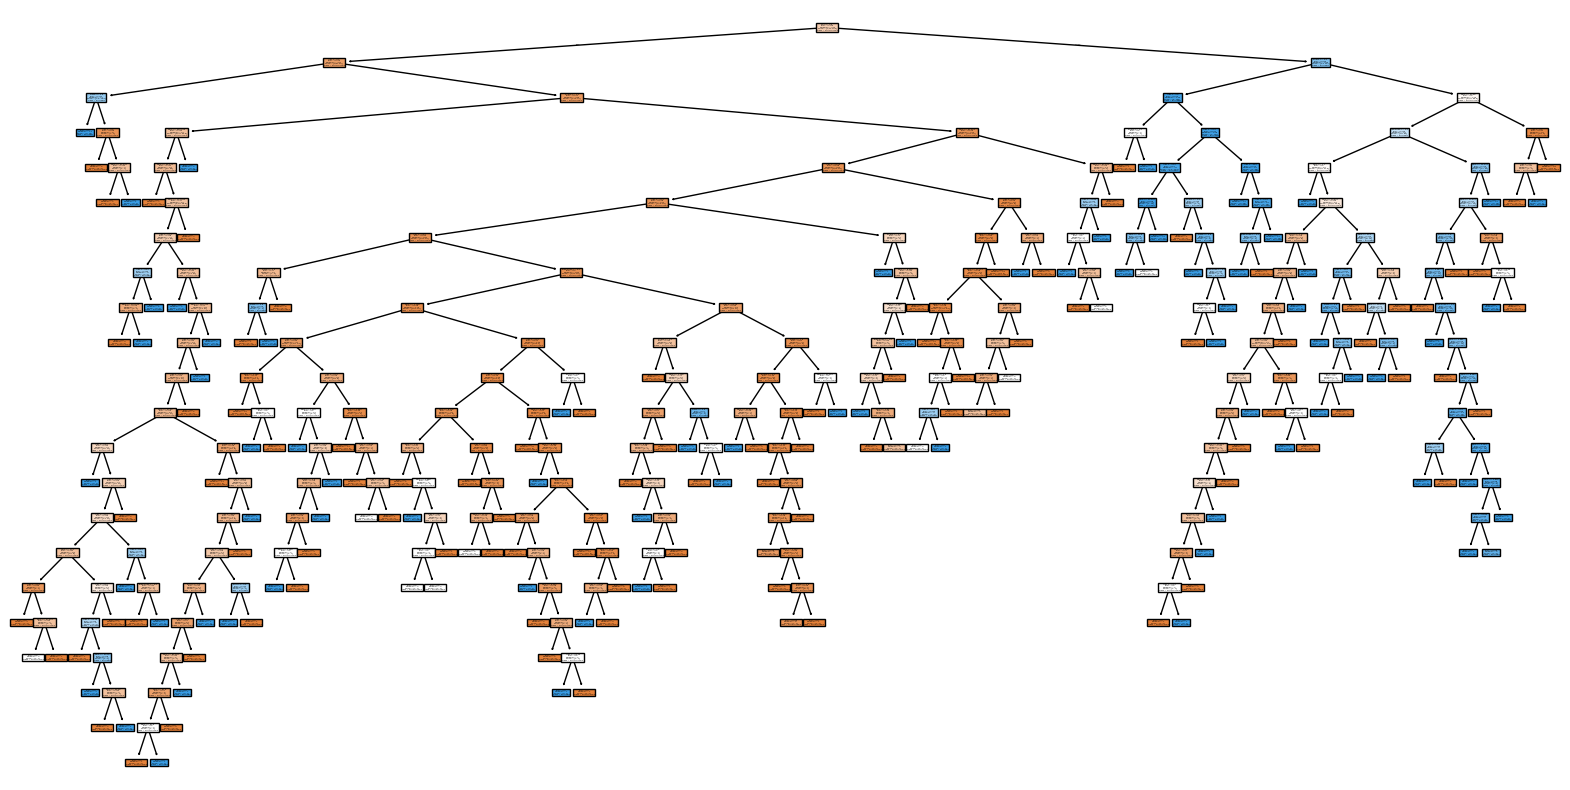

In [10]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=['Not Survived','Survived']
)

plt.show()

In [11]:
dt2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt2.fit(X_train, y_train)

pred2 = dt2.predict(X_test)

print(
    "Decision Tree Accuracy (Depth=3):",
    accuracy_score(y_test, pred2)
)

Decision Tree Accuracy (Depth=3): 0.7988826815642458


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8212290502793296


In [14]:
print("Decision Tree :", acc)

print("Random Forest :", rf_acc)

Decision Tree : 0.776536312849162
Random Forest : 0.8212290502793296


In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
5,Fare,0.269722
1,Sex,0.267356
2,Age,0.252813
0,Pclass,0.087029
3,SibSp,0.051220
4,Parch,0.037020
6,Embarked,0.034840


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)

print("Average Score:", scores.mean())

[0.7877095  0.80337079 0.84831461 0.7752809  0.84269663]
Average Score: 0.8114744837110036
